In [1]:
import matplotlib.pyplot as plt

In [3]:
import numpy as np

In [353]:
y = lambda x: 0.73 * x + 0.076

In [364]:
xs = np.arange(-1, 1, .1)

In [365]:
xs

array([-1.00000000e+00, -9.00000000e-01, -8.00000000e-01, -7.00000000e-01,
       -6.00000000e-01, -5.00000000e-01, -4.00000000e-01, -3.00000000e-01,
       -2.00000000e-01, -1.00000000e-01, -2.22044605e-16,  1.00000000e-01,
        2.00000000e-01,  3.00000000e-01,  4.00000000e-01,  5.00000000e-01,
        6.00000000e-01,  7.00000000e-01,  8.00000000e-01,  9.00000000e-01])

In [366]:
ys = y(xs)

In [367]:
ys

array([-0.654, -0.581, -0.508, -0.435, -0.362, -0.289, -0.216, -0.143,
       -0.07 ,  0.003,  0.076,  0.149,  0.222,  0.295,  0.368,  0.441,
        0.514,  0.587,  0.66 ,  0.733])

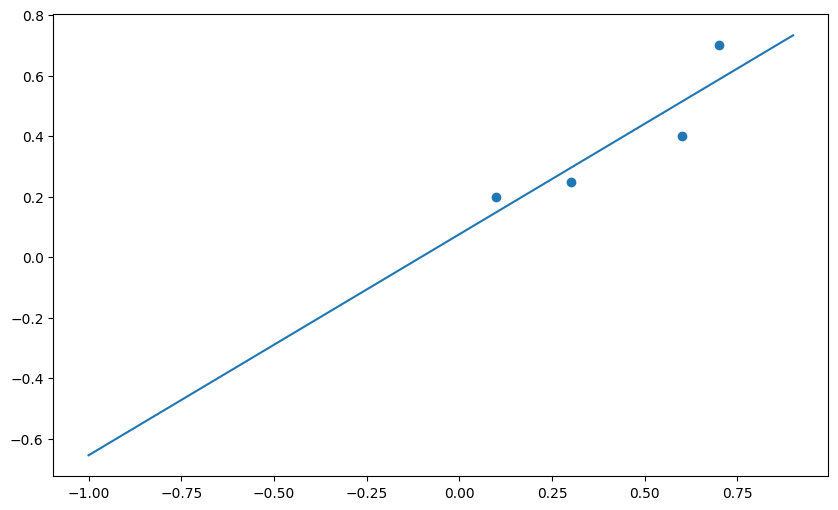

In [368]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(xs, ys)
ax.scatter(df['x'], df['y'])

In [13]:
fn = lambda x,y: x*x + 1 - y

In [17]:
fn(0, 0)

1

In [ ]:
# understand neural networks - part 1
# build a linear categorizer. Lets take an example line which divides a plane into two categories.
# L = x + y + 1
# Value of L will be +ve for all points on one side of the line, and value will be -ve for all points
# on the other side of the line. Zero for all points that are on the line (Here we are considering zero as +ve)
# We are given few points and our job is to come up with the weights that divides those lines to two categories.

In [6]:
L = lambda x,y: x - y + 1
activation = lambda v: 1 if v >= 0 else 0

In [2]:
import numpy as np

In [5]:
X = np.arange(-10, 10, 1)
Y = np.arange(-10, 10 , 1)

In [11]:
E = []
inputs = []
for x in X:
    for y in Y:
        inputs.append([x, y])
        E.append(activation(L(x,y)))


In [23]:
batch_size = 4

In [32]:
W = np.random.rand(2, 1)

In [104]:
W + np.array([[0.0], [0]])

array([[0.7332991 ],
       [0.62320134]])

In [52]:
B = np.array([1])

In [54]:
def process(Input, Weights, bias):
    o = (Input @ Weights) + bias
    return activation(o.item())

In [69]:
input_batches = np.split(inputs, inputs.shape[0]/batch_size)

In [68]:
output_batches = np.split(outputs, inputs.shape[0]/batch_size)

In [78]:
import math

In [108]:
for batch_in, batch_out in zip(input_batches[:1], output_batches[:1]):
    predicted_out = []
    losses = []

    # feed inputs
    for input in batch_in:
        predicted_out.append(process(input, W, B))

    # calculate loss
    for predicted, actual in zip(predicted_out, batch_out):
        losses.append((predicted - actual) ** 2 / batch_size)

    print(f"Batch loss {np.average(losses)}")

    # calculate gradients
    h = 0.1
    h1 = np.array([[h],[0]])
    h2 = np.array([[0], [h]])
    h3 = np.array([h])

    print(process(input, W + h1, B))

    gradW1 = (process(input, W + h1, B) - process(input, W, B)) / h
    gradW2 = (process(input, W + h2, B) - process(input, W, B)) / h
    gradB = (process(input, W, B + h3) - process(input, W, B)) / h

    # update weights
    print(f"{gradW1=} {gradW2=} {gradB=}")


Batch loss 0.125
0
gradW1=0.0 gradW2=0.0 gradB=0.0


In [ ]:
# before getting to the above example I would like to try the example given in the post below
# https://towardsdatascience.com/training-a-neural-network-by-hand-1bcac4d82a6e

# here we want to predict the output for the function of shape y = mx + c by using the input x values

In [119]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.DataFrame({
    'x': [0.1, 0.3, 0.6, 0.7],
    'y': [0.2, 0.25, 0.4, 0.7]
})

In [279]:
def activation(x):
    return x

def liner_combination(x, w, b):
    return x * w + b

def fn(x, w11, b1=0):
    return activation(liner_combination(x, w11, b1))

def err_fn(x,y, w11, b1):
    yp = activation(fn(x, w11, b1))
    # 1/2 MSE
    return ((y - yp) ** 2) / 2

In [303]:
def dofe_wrt_w11(x, y, w11, b1, dw11=1e-10):
    return (err_fn(x, y, w11 + dw11, b1) - err_fn(x,y, w11, b1)) / dw11


def dofe_wrt_bias(x, y, w11, b1, db1=1e-10):
    return (err_fn(x, y, w11, b1 + db1) - err_fn(x, y, w11, b1)) / db1

In [215]:
def cprint(arr):
    for a in arr:
        print("%.4f" % a)

In [342]:
# init
# lets take w11 as 0.5  initial weight and bias b1 as zero then the model predicted values are
W11 = w11 = 0.5
B1 = b1 = 0
LR1 = lr = 1 # learning rate

In [337]:
# lets now calculate errors
errs = err_fn(df['x'], df['y'], w11, b1)
print(sum(errs))

0.0825


In [338]:
# lets now find the derivative of error function wrt w11 and bias b1
# these are called gradients
w11grad = np.average(dofe_wrt_w11(df['x'], df['y'], w11, b1))
b1grad = np.average(dofe_wrt_bias(df['x'], df['y'], w11, b1))
(w11grad, b1grad)

(-0.08750000073456943, -0.17500001447956492)

In [339]:
# now using this gradients we can update weights and bias
w11 = w11 - lr * w11grad
b1 = b1 - lr * b1grad
(w11, b1)

(0.5875000007345694, 0.17500001447956492)

In [341]:
fn(df['x'], W11)

NameError: name 'W11' is not defined

In [349]:
def train(n):
    w11 = 0.5
    b1 = 0
    lr = 1
    
    def forward():
        errs = err_fn(df['x'], df['y'], w11, b1)
        print(sum(errs))

    def backward():
        w11grad = np.average(dofe_wrt_w11(df['x'], df['y'], w11, b1))
        b1grad = np.average(dofe_wrt_bias(df['x'], df['y'], w11, b1))
        wnew = w11 - lr * w11grad
        bnew = b1 - lr * b1grad
        return (wnew, bnew)


    for _ in range(n):
        forward()
        (w11, b1) = backward()

    print(f"{w11=}, {b1=}")

In [352]:
train(1000)

0.0825
0.020292970926331907
0.017804538336650546
0.017488331909440925
0.0172714441362845
0.01707730991451911
0.01690138418575926
0.01674188035617536
0.016597262762170138
0.016466141973468577
0.016347258280936264
0.016239469727829553
0.016141740510515683
0.016053132392529937
0.015972793754542743
0.015899953102922134
0.015833910409801977
0.015774031286382568
0.015719740510584345
0.015670516564843667
0.015625886713809725
0.015585421923950439
0.01554873359552466
0.015515469416582847
0.015485309763663014
0.015457964611390627
0.01543317140898516
0.01541069209012846
0.01539031083427864
0.015371831731399358
0.015355077215670884
0.015339886380772182
0.015326113232110193
0.015313625498403677
0.015302303223708213
0.015292037629089057
0.015282730088162891
0.015274291133466646
0.015266639834472136
0.01525970262351218
0.015253412833423394
0.015247710040113337
0.015242539488767061
0.015237851494827974
0.01523360100193784
0.015229747198291364
0.015226253065603322
0.015223085041259505
0.015220212718803

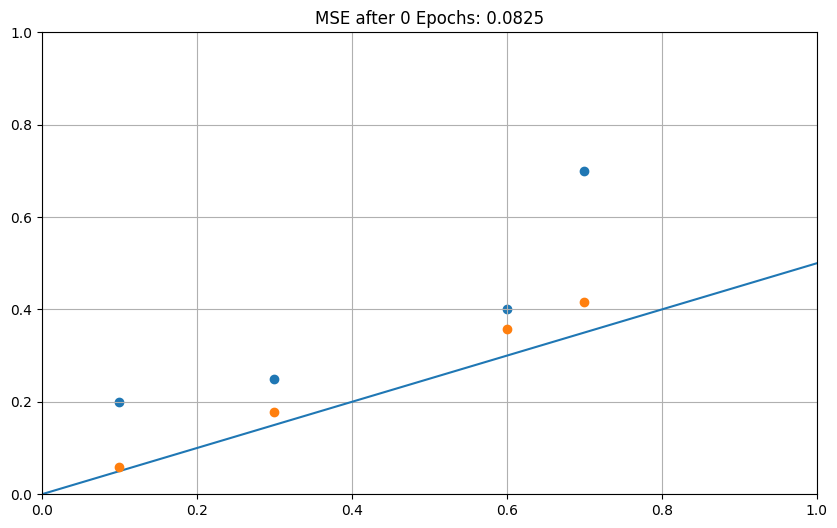

In [335]:
init_w11 = 0.5
init_b11 = 0
init_predictions = fn(df['x'], w11)

fig, ax = plt.subplots(figsize=(10, 6))
ax.axline((0, init_b11), slope=init_w11)
ax.scatter(df['x'], df['y'])
ax.scatter(df['x'], init_predictions, zorder=3)
ax.set_title("MSE after 0 Epochs: {}".format(0.0825))
ax.set_xlim([0,1])
ax.set_ylim([0,1])
ax.grid()